In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# On-Policy, Off-Policy, and Offline RL

Every algorithm in this chapter answers one question differently: which data may drive which update? PPO threw each batch away after a bounded number of reuse epochs, while DQN happily trained on transitions collected by policies that no longer exist. That difference was not a matter of taste. This section states the rule behind it, uses SARSA to show how one symbol in an update flips the answer, and then pushes the question to its limit: what happens when the robot may not interact at all and must learn from a fixed dataset? That setting is called offline reinforcement learning, or batch reinforcement learning in the older literature, since the data arrives as one fixed batch. It is how RL must operate when exploration is expensive or unsafe, and it fails in a specific, measurable way that we will produce and then repair on FrozenLake.

## Which Data May Drive Which Update

Look at what each family of updates estimates. The policy gradient of that section is an expectation under the *current* policy's trajectory distribution; a sample from any other policy estimates the wrong quantity. Methods with this property are on-policy: REINFORCE, the actor-critic of that section, and, with a bounded allowance, PPO. The allowance is exactly the one that section derived: importance ratios re-weight data from a nearby policy, the reweighting is exact in principle by the equation, and its variance explodes as the collecting policy drifts away, which is why PPO reuses a batch for a bounded number of epochs and no longer.

The Q-Learning update estimates something different. For a transition $(s, a, r, s')$, the target $r + \gamma \max_{a'} Q(s', a')$ is a sample of the Bellman optimality backup at $(s, a)$, and that backup depends on the environment alone: which $s'$ follows $(s, a)$ and which reward arrives. Nothing in it refers to the policy that happened to choose $a$. Any real transition, from yesterday's policy, from a random policy, from another robot, is a valid sample of the same quantity. Methods with this property are off-policy, and DQN's replay buffer is this license exercised at scale: the buffer holds transitions from every past version of the policy, and the update does not care.

SARSA makes the boundary sharp, because it sits one symbol away from Q-Learning [@Rummery.Niranjan.1994]. Its target uses the action $a'$ that the behavior policy *actually took* at $s'$,

$$y = r + \gamma\, Q(s', a'),$$

instead of the max. That one substitution changes what the update estimates: not the optimal backup, but the value of the policy generating the data, exploration and all. SARSA is therefore on-policy, and feeding it stale transitions estimates the value of a policy that no longer runs. One symbol, the opposite data rule; the exercises ask you to watch the two diverge on a common problem.

## Offline RL: Learning Without Touching the World

Now remove interaction entirely. A dataset of transitions is collected once, by some behavior policy we may not control, and the robot must produce the best policy it can from the dataset alone. No exploration, no second chances, no way to test a hypothesis by acting. This is the offline setting [@Levine.Kumar.Tucker.ea.2020], and it is the realistic one whenever data is plentiful but experimentation is costly: hospital records, driving logs, the interaction history of a deployed system.

Off-policy methods look like the obvious fit, since their updates accept data from any policy. Q-Learning on a fixed buffer is a well-defined algorithm: sweep over the dataset, apply the usual update, repeat until the values settle. Before running it, notice what we are asking of it. Doing better than the behavior policy means answering counterfactual queries, questions about actions the dataset never shows, and the only material for answering them is generalization from the actions it does show [@Levine.Kumar.Tucker.ea.2020]. Worse, the learned policy will prefer exactly the actions whose values its estimates have inflated, and those are disproportionately the actions the dataset supports least, so the value estimates get consulted precisely where they are least trained. This mismatch between the actions in the dataset and the actions the learned policy asks about is called distribution shift, and it is the standing condition of the offline setting. The catch, then, is not the validity of any single update. The catch is that that section's self-correction is gone. Online, an overestimated action soon gets chosen, tested, and corrected by fresh data. Offline, an overestimated action is chosen by the learned policy and nothing ever corrects it, because no new data arrives. And overestimation is guaranteed at some scale, for the reason that section gave: the target's max ranges over estimates whose errors reflect the accidents of a finite dataset, and a max over noisy estimates is biased upward. The max is not even a neutral consumer of this noise. Maximization hunts for the entries that err upward, the way any optimizer probes a model for its soft spots, so the errors that end up in the policy are the worst ones available rather than typical ones. The bias flows through bootstrapping into other states, and the final policy is built by taking argmaxes over exactly the entries most likely to be inflated.

To see this happen we need an environment with genuine randomness, so for the first time in this chapter we let the ice be slippery. In the slippery FrozenLake, each action moves the robot in the intended direction with probability $1/3$ and slides it to one of the two perpendicular directions with probability $1/3$ each. Values are now genuinely hard to estimate from few samples, which is precisely the condition under which the max misbehaves.

In [1]:

%matplotlib inline
import random
import numpy as np
import gymnasium as gym
from d2l import torch as d2l

gamma = 0.95  # Discount factor
num_episodes = 500  # Episodes in the fixed dataset
num_sweeps = 200  # Passes of offline Q-learning over the dataset
alpha = 0.2  # Learning rate
num_seeds = 5

def collect_dataset(seed, num_episodes):
    # A uniformly random behavior policy gathers the dataset once
    env = gym.make('FrozenLake-v1', is_slippery=True)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    buffer = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.append((state, action, reward, next_state,
                           float(terminated)))
            state = next_state
    return buffer

Offline Q-Learning sweeps over the frozen dataset until the values converge. The function takes a pessimism strength `kappa`, explained below; `kappa=0` is the naive algorithm.

In [2]:

def offline_q(buffer, num_sweeps, alpha, kappa=0.0):
    Q = np.zeros((16, 4))
    counts = np.zeros((16, 4))
    for s, a, *_ in buffer:
        counts[s, a] += 1
    # Penalty shrinks like 1/sqrt(n): rarely tried actions are distrusted
    penalty = kappa / np.sqrt(np.maximum(counts, 1))
    rng = np.random.default_rng(0)
    order = np.arange(len(buffer))
    for sweep in range(num_sweeps):
        rng.shuffle(order)
        for i in order:
            s, a, r, s2, terminal = buffer[i]
            if terminal:
                y = r
            else:
                y = r + gamma * np.max(Q[s2] - penalty[s2])
            Q[s, a] += alpha * (y - Q[s, a])
    return Q - penalty

def evaluate_greedy(Q, episodes=1500, seed=999):
    env = gym.make('FrozenLake-v1', is_slippery=True)
    env.reset(seed=seed)
    total = 0.0
    for _ in range(episodes):
        state, _ = env.reset()
        done, ret, disc = False, 0.0, 1.0
        while not done:
            state, r, terminated, truncated, _ = env.step(
                int(np.argmax(Q[state])))
            done = terminated or truncated
            ret += disc * r
            disc *= gamma
        total += ret
    return total / episodes

Because the slippery MDP is known to us (though not to the algorithm), we can also compute the true optimal value of the start state with the Value Iteration of that section, as the yardstick both methods will be measured against:

In [3]:

env = gym.make('FrozenLake-v1', is_slippery=True)
P = env.unwrapped.P
V = np.zeros(16)
for k in range(200):
    V_new = np.zeros(16)
    for s in range(16):
        V_new[s] = max(sum(p * (r + gamma * (0 if term else V[s2]))
                           for p, s2, r, term in P[s][a])
                       for a in range(4))
    V = V_new
v_star = V[0]
print(f'true optimal value of the start state: {v_star:.3f}')

true optimal value of the start state: 0.180


Now the experiment. For each seed we collect 500 episodes with the random policy, run naive offline Q-Learning and its pessimistic variant, and compare what each *predicts* the start state is worth against what its greedy policy *actually earns*:

naive: predicted value 0.301, actual return of the greedy policy 0.094
pessimistic: predicted value 0.167, actual return of the greedy policy 0.101


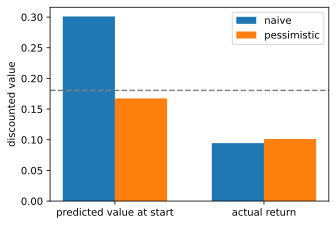

In [4]:

results = {'naive': ([], []), 'pessimistic': ([], [])}
for seed in range(num_seeds):
    buffer = collect_dataset(seed, num_episodes)
    for name, kappa in [('naive', 0.0), ('pessimistic', 0.1)]:
        Q = offline_q(buffer, num_sweeps, alpha, kappa)
        results[name][0].append(np.max(Q[0]))
        results[name][1].append(evaluate_greedy(Q))

bars = {}
for name, (pred, actual) in results.items():
    bars[name] = [np.median(pred), np.median(actual)]
    print(f'{name}: predicted value {np.median(pred):.3f}, '
          f'actual return of the greedy policy {np.median(actual):.3f}')
d2l.show_value_bars(bars, ['predicted value at start', 'actual return'],
                    'discounted value', reference=v_star)

Read the naive bars first. The algorithm predicts a start-state value around $0.30$. The dashed line is the true optimum, $0.18$: the prediction is above what *any* policy can achieve in this environment, which is overestimation caught red-handed, no baseline policy needed for the comparison. What the greedy policy actually earns is roughly $0.09$. The algorithm promises three times what it delivers, and in a real offline deployment the promise is the only number you would see before acting on the policy. Comparing what a method predicts against what it earns is the standard diagnostic of the field, and our factor of three is the gentle, tabular edition: run the same comparison with deep networks on continuous control and the predicted values run orders of magnitude above reality [@Levine.Kumar.Tucker.ea.2020].

## Pessimism

The repair follows from the diagnosis. The inflated entries are the poorly estimated ones, and poorly estimated means rarely observed, so distrust value in proportion to how little data supports it. The variant above implements the simplest version: subtract a penalty $\kappa / \sqrt{n(s, a)}$, where $n(s, a)$ counts the visits to that pair in the dataset, both inside the bootstrap max and from the final values. The $1/\sqrt{n}$ shape is the natural one, since that is the rate at which the noise in an average of $n$ samples shrinks. With $\kappa = 0.1$, the prediction drops to roughly $0.17$, in line with the true optimum instead of above it, and the actual return edges up to roughly $0.10$. Pessimism did not conjure a much better policy out of the same data; what it bought is a prediction the deployment could have trusted, and that is the currency of the offline setting. This under-promise principle, in many more sophisticated forms, runs through most of modern offline RL [@Levine.Kumar.Tucker.ea.2020].

The asymmetry with the online setting deserves one plain statement. Online, optimistic errors self-correct through action, so algorithms can afford optimism and even exploit it to explore. Offline, optimistic errors are never tested, so the safe direction of error is downward: what you cannot verify, you discount.

## Beyond the Gridworld

Our count-based penalty is the tabular seed of a family, and the three ideas below are where that family goes once states and actions are continuous and counts no longer exist.

The most direct descendants keep the same two worries and pick where to enforce them. The first diagnosis at deep-RL scale gave the disease we produced above its name, extrapolation error, and answered it on the policy side: restrict the learned policy to actions the dataset supports, so that the values it consults are ones the data can back [@Fujimoto.Meger.Precup.2019]. Conservative Q-Learning answers on the value side: train the values with an extra penalty that pushes down the estimates of out-of-data actions, so that the learned values lower-bound the truth instead of inflating it [@Kumar.Zhou.Tucker.ea.2020]. Continuous Doubly Constrained batch RL pairs the two, one regularizer against optimistic values and one against straying from the data [@Fakoor.Mueller.Asadi.ea.2021]. Constraining the policy, the values, or both is how a large share of practical offline methods operate.

A sharper version of the same thought asks *where* to deviate rather than how much to deviate everywhere. Every action that departs from the behavior policy is a counterfactual, a claim about what would have happened if, and the extrapolation errors these claims carry compound along the horizon. Since not every decision step matters equally to the outcome, one can grant the policy a fixed budget of departures and use dynamic programming to place them at the steps where deviating pays [@Liu.Chaudhari.Fakoor.2023].

There is also a way out of the bootstrapping business altogether. The max in the target caused the inflation, so drop the max, drop the bootstrap, and treat the dataset as sequences to be modeled. The Decision Transformer [@Chen.Lu.Rajeswaran.ea.2021] trains an autoregressive sequence model, the same family as the language models later in this book, on trajectories written as alternating returns-to-go, states, and actions; at test time it is conditioned on a high desired return and generates the actions that would earn it. Offline RL becomes supervised sequence prediction, with no value function and no maximization anywhere, and on standard benchmarks this matches strong value-based offline methods. How far the sequence-modeling view carries is an active argument, and it is one of the bridges from this chapter to reinforcement learning for language models.

## Summary

On-policy updates estimate expectations under the current policy and spoil when the data comes from anyone else; importance ratios extend their reach only as far as their variance allows. Off-policy updates like Q-Learning's estimate the Bellman optimality backup, which depends on the environment and not on the data collector, so replay across stale policies is legitimate. SARSA differs from Q-Learning by evaluating the action actually taken instead of the max, which is exactly the difference between estimating the behavior policy's value and the optimal one, and between on-policy and off-policy. Offline RL removes interaction altogether: the max over finitely-sampled values overestimates, nothing corrects it, and the learned policy is assembled from the most inflated entries. On slippery FrozenLake the naive method predicted more than the theoretical optimum and delivered a third of its promise; a $1/\sqrt{n}$ pessimism penalty restored honest predictions at the same data budget. Past the gridworld, the same instincts scale as paired value and policy constraints, as explicit budgets on out-of-distribution actions, and as the sequence-modeling route that drops value bootstrapping entirely.

## Exercises

1. Implement SARSA on the non-slippery FrozenLake of that section with a fixed $\epsilon = 0.3$, alongside Q-Learning with the same exploration. Compare the greedy policies and the values each converges to, and explain the difference in terms of what each update estimates.
1. Rerun the offline experiment with datasets of 100, 500, and 2000 episodes. How do the predicted and actual values move? Does more random data close the gap by itself?
1. Sweep $\kappa$ over $\{0.02, 0.1, 0.3, 1.0\}$. Describe both failure directions: what happens when pessimism is too weak, and when it is too strong?
1. Replace the count-based penalty with a support constraint: in the bootstrap max, allow only actions with $n(s', a') > 0$. This is the tabular form of batch-constrained Q-learning [@Fujimoto.Meger.Precup.2019]. On this dataset the two behave similarly; construct a behavior policy for which they differ.